# All-URLs Extraction Performance — 200-Paper Sample

This notebook evaluates how well each document format (and combinations of formats) recover the **full set of human-labelled ground-truth URLs** (`data/200_sample/arxiv_urls_1992_2024_gt.csv`) found in the 200 sampled arXiv papers. 

For the narrower question of *open access dataset & software URLs* specifically (the OADS categories), see the companion notebook `arxiv_200_oads_urls_extraction_performance.ipynb`. That notebook shares the same data-preparation step as this one but then diverges into its own, separate analysis. 

## What this notebook does

1. **Data preparation** — loads the per-format URL-extraction results, and
   builds a combined "superset" JSON keyed by arXiv ID
2. **Ground-truth characterization** — where in the paper labelled URLs
   tend to appear, and how visually/lexically complex they are
3. **Domain- and protocol-level coverage** — which domains / URL schemes
   each format tends to miss
4. **All-URLs Recall / Precision / F1** — bootstrapped, with 95% CIs,
   across every combination of the 6 single-format extractors
5. **Significance testing** — Friedman test (global difference across the
   6 formats) followed by Wilcoxon signed-rank + Holm–Bonferroni
   (pairwise, vs. the best single-format baseline)

## Data layout

```
data/200_sample/
├── arxiv_extracted_urls_all_formats_200.json   # REQUIRED: output of arxiv_200_benchmark_conversions_and_extractions.ipynb
├── arxiv_urls_1992_2024_gt.csv                 # REQUIRED: human-labelled ground truth
└── analysis/                                    # generated by this notebook
    ├── arxiv_extracted_unique_urls_all_200_superset.json
    ├── all_urls_63_combos.csv
    ├── friedman_all_url_recall.csv
    └── significance_all_url_recall_holm.csv

results/                                          # generated figures (PDF)
```

<!-- ## A note on the ground-truth `oads` key

Several cells below use `paper_data['oads']['oads_info']` as the list of
`{url, oads_label}` ground-truth entries for a paper. This notebook
**assumes that key already exists** in the superset JSON — it is expected
to have been attached upstream from your OADS-category labelling step
(the exact CSV → label mapping wasn't available when this notebook was
put together, so it isn't reconstructed here). If your superset JSON
doesn't have an `oads` key yet, attach it before running the cells that
need it — everything else in this notebook (sections 1–3) does not
require it. -->

## 1. Data preparation

Shared with `arxiv_200_oads_urls_extraction_performance.ipynb` — both notebooks start from the same
merged ground truth and superset JSON, then diverge into their own
analyses. This section is intentionally duplicated in both notebooks so
each one can be run standalone.

### 1.1 Paths

In [30]:
import json
from pathlib import Path

DATA_DIR      = Path("data/200_sample")
RESULTS_DIR   = Path("results")
ANALYSIS_DIR  = DATA_DIR / "analysis"
LABELS = DATA_DIR / "arxiv_urls_1992_2024_gt.csv"
EXTRACTION_JSON = DATA_DIR / "arxiv_extracted_urls_all_formats_200.json"
SUPERSET_JSON   = ANALYSIS_DIR / "arxiv_extracted_unique_urls_all_200_superset.json"

for d in [ANALYSIS_DIR, RESULTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SINGLE_FORMATS = ["textwal_pymupdf", "latex", "html", "xml", "vlm_qwen", "markdown"]

FORMAT_LABELS = {
    "textwal_pymupdf":  "TEXTWAL",
    "latex":    "LaTeX",
    "html":     "HTML",
    "xml":      "XML",
    "vlm_qwen": "Qwen2-VL",
    "markdown": "Markdown",
}

### 1.2 Read the human-labelled ground truth

In [34]:
import pandas as pd

df_labels = pd.read_csv(LABELS, dtype={"arxiv_id": str})
print(f"Rows before de-duplication : {len(df_labels)}")

df_labels_u = df_labels.drop_duplicates(subset=['arxiv_id', 'URL'], keep='first')
print(f"Rows after de-duplication  : {len(df_labels_u)}")

Rows before de-duplication : 2420
Rows after de-duplication  : 2338


### 1.3 Load per-format extraction results and build the superset JSON

Loads the combined per-format URL-extraction output (from
`arxiv_200_benchmark_conversions_and_extractions.ipynb`), attaches the ground-truth URLs
for each paper under a `pdf` key (used as the "available in the source
PDF" ground truth throughout this notebook), and computes each paper's
`superset` — the union of URLs found across every format.

In [21]:
with open(EXTRACTION_JSON, 'r', encoding='utf-8') as f:
    arxiv_all_200 = json.load(f)

print(f"Papers in extraction JSON: {len(arxiv_all_200)}")

# Attach ground-truth URLs (per paper) under a 'pdf' key
for arxiv_id, paper_data in arxiv_all_200.items():
    gt_urls = sorted(set(df_labels_u.loc[df_labels_u['arxiv_id'] == arxiv_id, 'URL'].dropna()))
    paper_data['pdf'] = {"urls": gt_urls, "url_count": len(gt_urls)}

total_gt = sum(v['pdf']['url_count'] for v in arxiv_all_200.values())
print(f"Total ground-truth URLs attached: {total_gt}")

Papers in extraction JSON: 200
Total ground-truth URLs attached: 2338


### 1.4 Assign OADS label for each Ground Truth URL

In [23]:
for key in arxiv_all_200.keys():
    arxiv_all_200[key]['oads'] = {
        'oads_info': [],
        'url_count': 0
    }

oads_count = 0
for key in arxiv_all_200.keys():
    # if key in arxiv_ids_pdf:
    temp_df = df_labels_u[df_labels_u['arxiv_id'] == key]
    
    # # Remove duplicate URLs but keep their OADS label
    # temp_df= temp_df.drop_duplicates(subset=['URL'], keep='first', inplace=False)
    
    # Create paired structure
    oads_info = (
        temp_df[['URL', 'OADS']]
        .rename(columns={'URL': 'url','OADS': 'oads_label'})
        .to_dict('records')
    )
    
    # Store
    arxiv_all_200[key]['oads']['oads_info'] = oads_info
    arxiv_all_200[key]['oads']['url_count'] = len(oads_info)
    
    oads_count += len(oads_info)

In [24]:
ALL_EXTRACTION_KEYS = [
    "text", "textwal_pymupdf", "textwal_pypdf", "textwal_pdfminer", "textwalcl",
    "html", "latex", "xml", "markdown",
    "vlm_qwen", "vlm_deepseek", "vlm_minicpm",
]

for paper_data in arxiv_all_200.values():
    union_urls = set()
    for fmt in ALL_EXTRACTION_KEYS:
        fmt_data = paper_data.get(fmt, {})
        union_urls.update(fmt_data.get("urls", []) or [])
    paper_data["superset"] = {"urls": sorted(union_urls), "url_count": len(union_urls)}

with open(SUPERSET_JSON, 'w', encoding='utf-8') as f:
    json.dump(arxiv_all_200, f, indent=2)

print(f"Saved -> {SUPERSET_JSON}")

Saved -> data/200_sample/analysis/arxiv_extracted_unique_urls_all_200_superset.json


### 1.4 Shared helper

Used throughout the rest of this notebook to get the union of URLs
extracted by a given set of formats for one paper.

In [26]:
def get_extracted_urls(paper_data: dict, formats) -> set:
    """Union of extracted URLs across all formats in `formats` for one paper."""
    urls = set()
    for fmt in formats:
        fmt_data = paper_data.get(fmt, {})
        if 'url_info' in fmt_data:
            urls.update(x['url'] for x in fmt_data['url_info'])
        elif 'urls' in fmt_data:
            urls.update(fmt_data['urls'] or [])
    return urls

## 2. Ground-truth characterization

Where in the paper do labelled URLs tend to appear, and how visually /
lexically complex are they? This describes the ground truth itself, not
any extraction method.

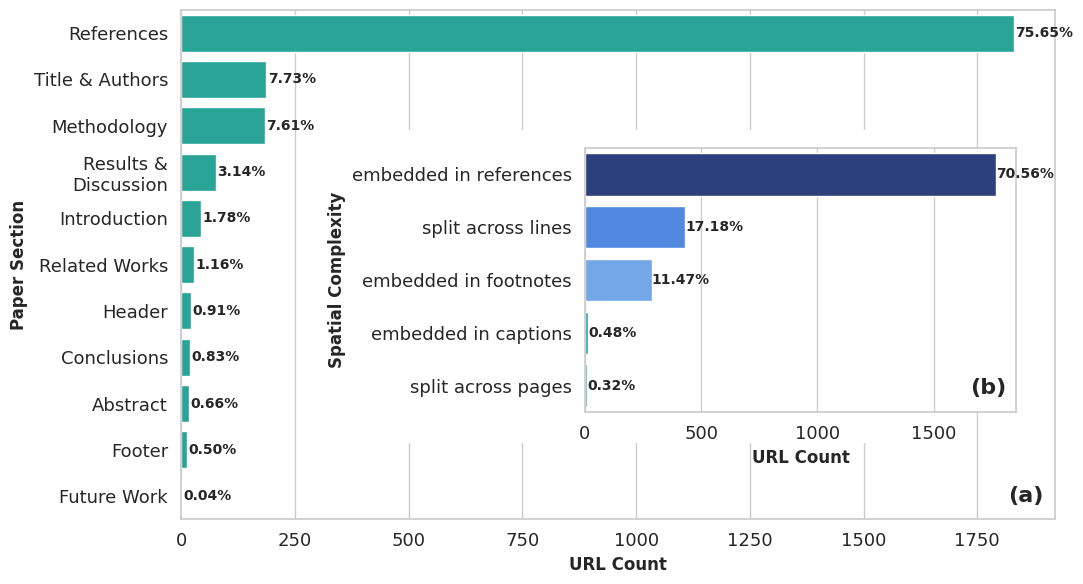

In [68]:
%matplotlib inline
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle

sns.set_theme(style="whitegrid", palette="muted")

# 7-color palette for the inset plot
palette = ['#1e3a8a', '#3b82f6', '#60a5fa', '#06b6d4', '#14b8a6', '#10b981', '#84cc16']

# --- Main plot data: paper section ('location') ---
df_loc = df_labels.assign(location=df_labels['location'].str.split(';')).explode('location')
df_loc['location'] = df_loc['location'].str.strip()
loc_counts = df_loc['location'].value_counts().sort_values(ascending=False)
loc_counts = loc_counts.rename(index={
    'Related Works & Background': 'Related Works',
    'Results and Discussion': 'Results &\nDiscussion',
})

# --- Inset plot data: spatial complexity ---
def split_spatial(text):
    if pd.isna(text):
        return []
    parts = re.findall(r'"([^"]+)"|([^,]+)', text)
    return [p[0].strip() if p[0] else p[1].strip() for p in parts if (p[0] or p[1])]

df_spatial = df_labels.assign(Spatial=df_labels['Spatial Complexity'].apply(split_spatial)).explode('Spatial')
df_spatial['Spatial'] = df_spatial['Spatial'].str.strip()
spatial_counts = df_spatial['Spatial'].value_counts()

# --- Plot: main (paper section) + inset (spatial complexity) ---
fig, ax1 = plt.subplots(figsize=(11, 6))
sns.barplot(y=loc_counts.index, x=loc_counts.values, color="#14b8a6", ax=ax1)

for p in ax1.patches:
    width = p.get_width()
    if width > 0:
        ax1.annotate(f'{width / loc_counts.sum() * 100:.2f}%',
                     (width + 3, p.get_y() + p.get_height() / 2),
                     va='center', ha='left', size=10, fontweight='bold')

ax1.set_xlabel("URL Count", fontweight='bold', fontsize=12)
ax1.set_ylabel("Paper Section", fontweight='bold', fontsize=12)
ax1.tick_params(axis='both', labelsize=13)
plt.tight_layout()

# left, bottom, width_ax, height = 0.513, 0.27, 0.42, 0.44
left, bottom, width_ax, height = 0.539, 0.30, 0.392, 0.44
ax2 = fig.add_axes([left, bottom, width_ax, height])


bg_patch = Rectangle((left - 0.25, bottom - 0.05), width_ax + 0.16, height + 0.08,
                     fill=True, color='white', transform=fig.transFigure, zorder=2)
fig.patches.append(bg_patch)


ax2.set_facecolor('white')
ax2.patch.set_alpha(1.0)
ax2.set_zorder(3)

sns.barplot(y=spatial_counts.index, x=spatial_counts.values, hue=spatial_counts.index,
            palette=palette[:len(spatial_counts)], legend=False, ax=ax2)

for p in ax2.patches:
    width = p.get_width()
    if width > 0:
        # Using a slightly smaller offset (+1 instead of +3) 
        ax2.annotate(f'{width / spatial_counts.sum() * 100:.2f}%',
                     (width + 1, p.get_y() + p.get_height() / 2),
                     va='center', ha='left', size=10, fontweight='bold')

ax2.set_xlabel("URL Count", fontsize=12, fontweight='bold')
ax2.set_ylabel("Spatial Complexity", fontsize=12, fontweight='bold')
ax2.tick_params(axis='both', labelsize=13)

fig.text(0.94, 0.15, '(a)', fontsize=16, fontweight='bold', ha='center')
fig.text(0.906, 0.33, '(b)', fontsize=16, fontweight='bold', ha='center')

plt.savefig(RESULTS_DIR / 'url_complexity_location_spatial.pdf', format="pdf", bbox_inches='tight')
plt.show()

## 3. Domain- and protocol-level coverage

For every ground-truth URL, mark whether each single format extracted it,
then look at which **domains** and **URI schemes** tend to be missed.

### 3.1 Build the per-URL availability table

In [36]:
rows = []
for arxiv_id, paper_data in arxiv_all_200.items():
    gt_urls = paper_data['pdf']['urls']
    extracted_by_fmt = {fmt: get_extracted_urls(paper_data, (fmt,)) for fmt in SINGLE_FORMATS}
    for url in gt_urls:
        row = {"arxiv_id": arxiv_id, "url": url}
        for fmt in SINGLE_FORMATS:
            row[fmt] = int(url in extracted_by_fmt[fmt])
        rows.append(row)

df_valid = pd.DataFrame(rows)
print(f"Ground-truth URL rows: {len(df_valid)}")
df_valid.to_csv(ANALYSIS_DIR / "url_format_availability.csv", index=False)

Ground-truth URL rows: 2338


### 3.2 Domain coverage heatmap

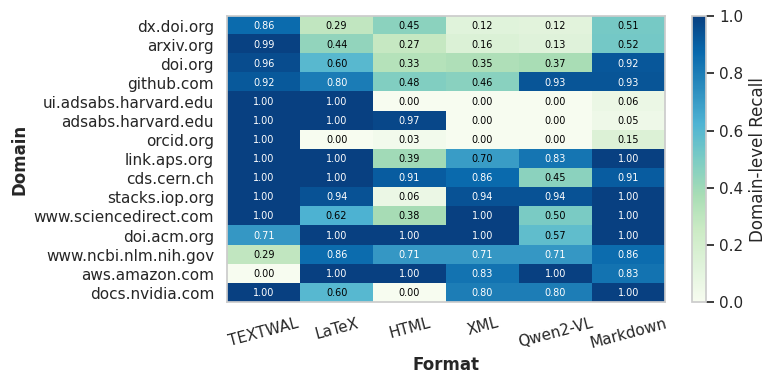

In [37]:
from urllib.parse import urlparse

df_valid['domain'] = df_valid['url'].apply(lambda u: urlparse(u).netloc)
df_valid_domains = df_valid[df_valid['domain'] != '']

TOP_N = 15
top_domains = df_valid_domains['domain'].value_counts().head(TOP_N).index

coverage = pd.DataFrame(index=top_domains, columns=SINGLE_FORMATS, dtype=float)
for fmt in SINGLE_FORMATS:
    extracted = df_valid_domains[df_valid_domains[fmt] == 1]['domain'].value_counts()
    missed = df_valid_domains[df_valid_domains[fmt] == 0]['domain'].value_counts()
    stats = pd.DataFrame({'extracted': extracted, 'missed': missed}).reindex(top_domains).fillna(0)
    coverage[fmt] = stats['extracted'] / (stats['extracted'] + stats['missed'])

plt.figure(figsize=(8, 4))
im = plt.imshow(coverage.values, aspect='auto', vmin=0, vmax=1, cmap='GnBu')
plt.colorbar(im, label="Domain-level Recall")
plt.xticks(np.arange(len(SINGLE_FORMATS)), [FORMAT_LABELS[f] for f in SINGLE_FORMATS], rotation=15, ha='center')
plt.yticks(np.arange(len(top_domains)), top_domains)
plt.xlabel("Format", fontweight='bold')
plt.ylabel("Domain", fontweight='bold')

for i in range(len(top_domains)):
    for j in range(len(SINGLE_FORMATS)):
        val = coverage.iloc[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                      color="white" if val > 0.7 else "black")

plt.grid(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'domain_coverage.pdf', format='pdf')
plt.show()

### 3.3 Protocol (URI scheme) coverage heatmap

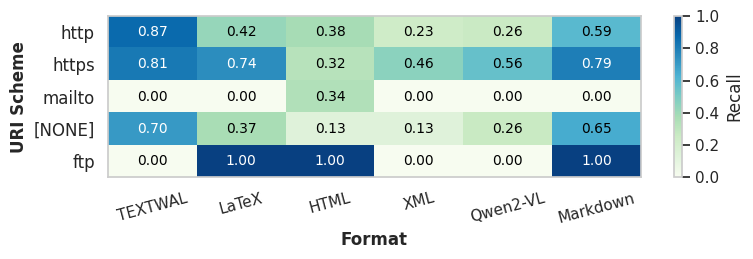

In [38]:
df_valid['protocol'] = df_valid['url'].apply(lambda u: urlparse(u).scheme).replace('', 'none')
df_proto = df_valid[df_valid['protocol'] != 'arxiv']
protocols = df_proto['protocol'].value_counts().index

heatmap_data = pd.DataFrame(index=protocols, columns=SINGLE_FORMATS, dtype=float)
for fmt in SINGLE_FORMATS:
    extracted = df_proto[df_proto[fmt] == 1]['protocol'].value_counts()
    missed = df_proto[df_proto[fmt] == 0]['protocol'].value_counts()
    stats = pd.DataFrame({'extracted': extracted, 'missed': missed}).reindex(protocols).fillna(0)
    heatmap_data[fmt] = stats['extracted'] / (stats['extracted'] + stats['missed'])

plt.figure(figsize=(8, 2.75))
im = plt.imshow(heatmap_data.values, aspect='auto', vmin=0, vmax=1, cmap='GnBu')
plt.colorbar(im, label="Recall")
plt.xticks(np.arange(len(SINGLE_FORMATS)), [FORMAT_LABELS[f] for f in SINGLE_FORMATS], rotation=15, ha='center')
plt.yticks(np.arange(len(protocols)), ['[NONE]' if p == 'none' else p for p in protocols], fontsize=12)
plt.xlabel("Format", fontweight='bold')
plt.ylabel("URI Scheme", fontweight='bold')

for i in range(len(protocols)):
    for j in range(len(SINGLE_FORMATS)):
        val = heatmap_data.iloc[i, j]
        if not np.isnan(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10,
                      color="white" if val > 0.7 else "black")

plt.grid(False)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'protocol_coverage.pdf', format='pdf')
plt.show()

## 4. All-URLs Recall / Precision / F1 across all 63 format combinations

Bootstrapped (B=10,000 resamples over the 200 papers) Recall, Precision,
and F1 for every non-empty combination of the 6 single formats, against
the full human-labelled ground truth (`pdf` key built in section 1.3).

In [39]:
import numpy as np
from itertools import combinations

all_combos = []
for r in range(1, len(SINGLE_FORMATS) + 1):
    all_combos.extend(combinations(SINGLE_FORMATS, r))

# --- Precompute per-paper ground-truth count and per-combo extraction stats ---
gt_per_paper = []
ext_total_per_paper = {combo: [] for combo in all_combos}
vp_per_paper = {combo: [] for combo in all_combos}
valid_papers = []

for arxiv_id, paper_data in arxiv_all_200.items():
    gt_urls = set(paper_data['pdf']['urls'])
    if not gt_urls:
        continue
    valid_papers.append(arxiv_id)
    gt_per_paper.append(len(gt_urls))

    for combo in all_combos:
        extracted = get_extracted_urls(paper_data, combo)
        vp_per_paper[combo].append(len(gt_urls & extracted))
        ext_total_per_paper[combo].append(len(extracted))

gt_arr = np.array(gt_per_paper)
ext_total_arrs = {c: np.array(ext_total_per_paper[c]) for c in all_combos}
vp_arrs = {c: np.array(vp_per_paper[c]) for c in all_combos}

print(f"Papers with ground-truth URLs: {len(valid_papers)}")
print(f"Total ground-truth URLs      : {gt_arr.sum()}")

Papers with ground-truth URLs: 190
Total ground-truth URLs      : 2338


In [77]:
# --- Bootstrap ---
np.random.seed(42)
n_iterations = 10_000
n_papers = len(valid_papers)
paper_indices = np.arange(n_papers)

bootstrapped_metrics = {combo: {'P': [], 'R': [], 'F1': []} for combo in all_combos}

for _ in range(n_iterations):
    indices = np.random.choice(paper_indices, size=n_papers, replace=True)
    total_gt = gt_arr[indices].sum()
    for combo in all_combos:
        total_ext = ext_total_arrs[combo][indices].sum()
        total_vp = vp_arrs[combo][indices].sum()
        p = total_vp / total_ext if total_ext > 0 else 0
        r = total_vp / total_gt if total_gt > 0 else 0
        f1 = (2 * p * r) / (p + r) if (p + r) > 0 else 0
        bootstrapped_metrics[combo]['P'].append(p)
        bootstrapped_metrics[combo]['R'].append(r)
        bootstrapped_metrics[combo]['F1'].append(f1)

# --- Final point estimates + 95% CIs ---
results = []
actual_gt = gt_arr.sum()

for combo in all_combos:
    label = " + ".join(FORMAT_LABELS[f] for f in combo)
    actual_ext = ext_total_arrs[combo].sum()
    actual_vp = vp_arrs[combo].sum()
    actual_p = actual_vp / actual_ext if actual_ext > 0 else 0
    actual_r = actual_vp / actual_gt if actual_gt > 0 else 0
    actual_f1 = (2 * actual_p * actual_r) / (actual_p + actual_r) if (actual_p + actual_r) > 0 else 0

    results.append({
        'Format Combination': label,
        'N_Formats': len(combo),
        'AllURLs_Total_Extracted': actual_ext,
        'AllURLs_VP': actual_vp,
        'AllURLs_GT_Total': actual_gt,
        'AllURLs_Precision': round(actual_p, 4),
        'AllURLs_P_95%_CI_Lower': round(np.percentile(bootstrapped_metrics[combo]['P'], 2.5), 4),
        'AllURLs_P_95%_CI_Upper': round(np.percentile(bootstrapped_metrics[combo]['P'], 97.5), 4),
        'AllURLs_Recall': round(actual_r, 4),
        'AllURLs_R_95%_CI_Lower': round(np.percentile(bootstrapped_metrics[combo]['R'], 2.5), 4),
        'AllURLs_R_95%_CI_Upper': round(np.percentile(bootstrapped_metrics[combo]['R'], 97.5), 4),
        'AllURLs_F1': round(actual_f1, 4),
        'AllURLs_F1_95%_CI_Lower': round(np.percentile(bootstrapped_metrics[combo]['F1'], 2.5), 4),
        'AllURLs_F1_95%_CI_Upper': round(np.percentile(bootstrapped_metrics[combo]['F1'], 97.5), 4),
    })

df_combos = pd.DataFrame(results).sort_values(by=['N_Formats', 'AllURLs_Recall'], ascending=[True, False])
df_combos.to_csv(ANALYSIS_DIR / "all_urls_63_combos.csv", index=False)
print(f"Saved -> {ANALYSIS_DIR / 'all_urls_63_combos.csv'}")

Saved -> data/200_sample/analysis/all_urls_63_combos.csv


### 4.1 Plot: F1 across all 63 combinations

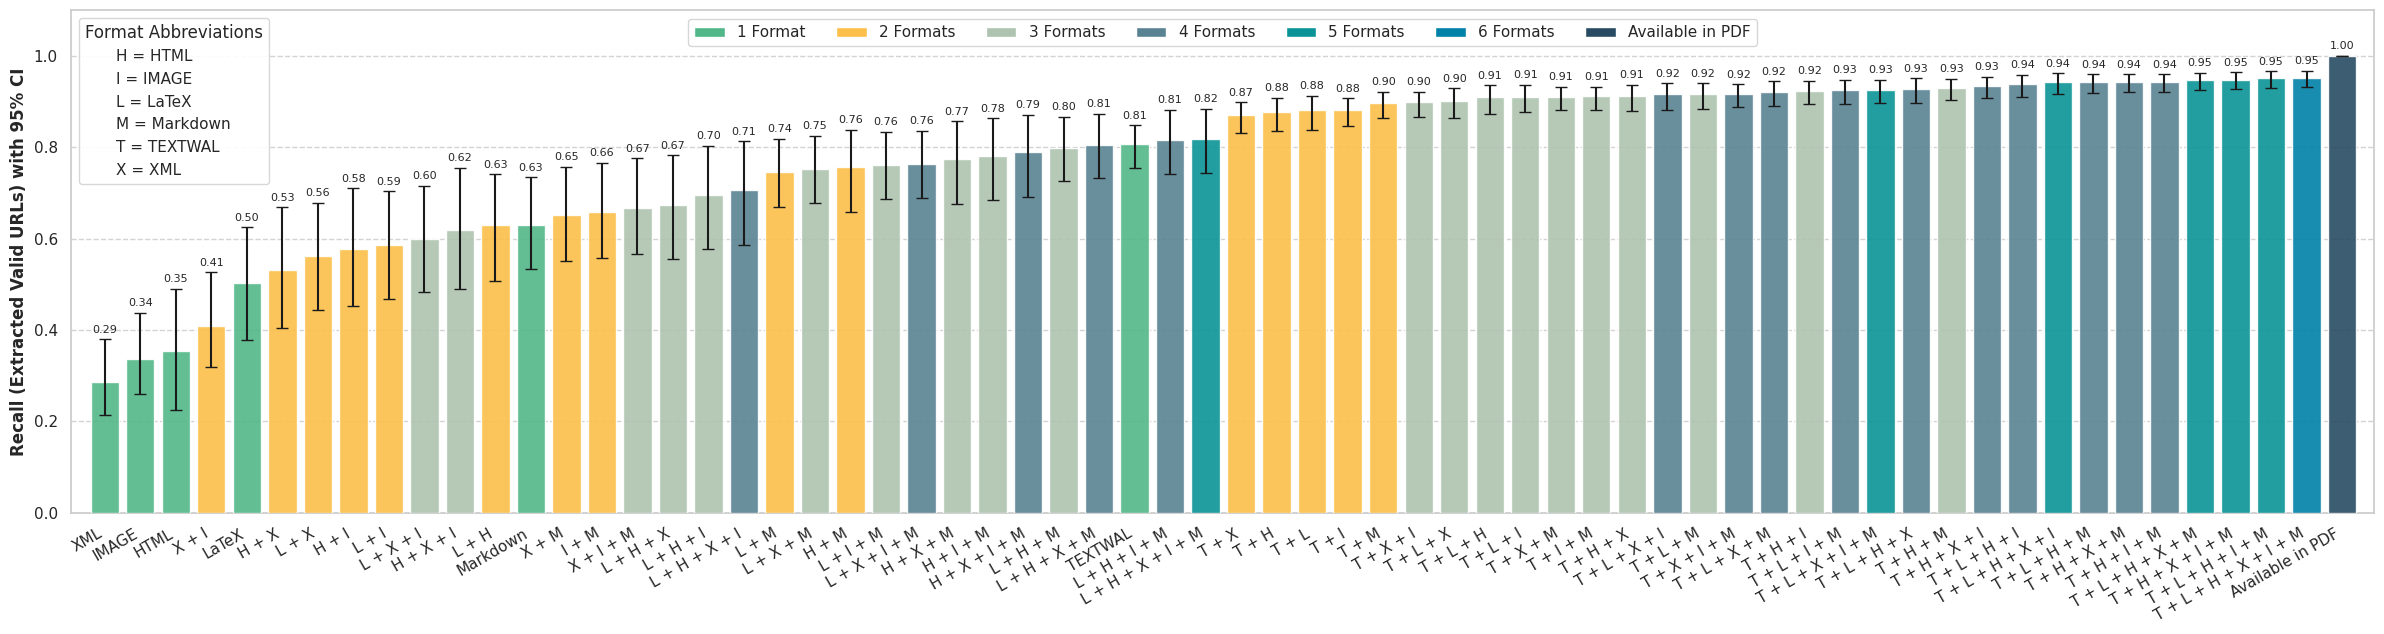

In [73]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import os

# Create directory
os.makedirs('results', exist_ok=True)

df = df_combos.copy()

# 2. Rename columns 
df = df.rename(columns={
    'Format Combination': 'label',
    'N_Formats': 'n_formats',
    'AllURLs_Recall': 'recall',
    'AllURLs_R_95%_CI_Lower': 'lower_ci',
    'AllURLs_R_95%_CI_Upper': 'upper_ci'
})

# 3. Sort by recall
df = df.sort_values('recall')

# --- Dynamic Abbreviations & Label Formatting ---

# Dynamically find unique formats to build the abbreviation map
unique_formats = set()
for label in df['label']:
    if '+' in label:
        unique_formats.update([f.strip() for f in label.split('+')])
    elif ',' in label:
        unique_formats.update([f.strip() for f in label.split(',')])
    else:
        unique_formats.add(label.strip())

# Build the abbreviation mapping for the top-left legend
abbr_mapping = {}
for f in unique_formats:
    if f == 'Qwen2-VL':
        abbr_mapping['I'] = 'IMAGE'
    else:
        abbr_mapping[f[0].upper()] = f

# Function to apply the requested label formatting rules
def format_x_label(label):
    # Determine separator and extract parts
    if '+' in label:
        parts = [p.strip() for p in label.split('+')]
    elif ',' in label:
        parts = [p.strip() for p in label.split(',')]
    else:
        parts = [label.strip()]

    # Single format scenario
    if len(parts) == 1:
        return 'IMAGE' if parts[0] == 'Qwen2-VL' else parts[0]

    # Multiple format scenario
    abbrs = ['I' if p == 'Qwen2-VL' else p[0].upper() for p in parts]
    return ' + '.join(abbrs)

# 4. Prepare plot data
labels = [format_x_label(lbl) for lbl in df['label'].tolist()]
recalls = df['recall'].tolist()
n_formats_list = df['n_formats'].tolist()

# Error bars (relative to mean)
lower_err = [r - l for r, l in zip(recalls, df['lower_ci'])]
upper_err = [u - r for u, r in zip(df['upper_ci'], recalls)]

# --- ADD THE MISSING BASELINE ---
labels.append('Available in PDF')
recalls.append(1.0)
n_formats_list.append('gt')  # 'gt' acts as the key for our color palette
lower_err.append(0.0)
upper_err.append(0.0)

# 5. Plotting with updated color palette
color_palette = {
    1: "#52b788", # (1 Format)
    2: "#fcbf49", # (2 Formats)
    3: "#aec3b0", # (3 Formats)
    4: "#598392", # (4 Formats)
    5: "#0a9396", # (5 Formats)
    6: "#0081a7", # (6 Formats)
    'gt': "#284b63" # (Available in PDF)
}

colors = [color_palette[n] for n in n_formats_list]

plt.figure(figsize=(24, 6.5))
bars = plt.bar(labels, recalls, color=colors, yerr=[lower_err, upper_err], capsize=4, zorder=3, alpha=0.9)

ax = plt.gca()
ax.margins(x=0)
ax.set_xlim(-0.95, len(labels)-0.1)

# Annotate bars neatly
for i, bar in enumerate(bars):
    height = bar.get_height()
    y_pos = recalls[i] + upper_err[i] + 0.01
    plt.text(bar.get_x() + bar.get_width() / 2, y_pos, f"{height:.2f}", 
             ha="center", va="bottom", fontsize=8, rotation=0)

plt.xticks(rotation=30, ha="right", fontsize=11)

plt.ylabel("Recall (Extracted Valid URLs) with 95% CI",fontsize=12, fontweight="bold")
plt.ylim(0, 1.1)
plt.grid(axis="y", linestyle="dashed", color="lightgray", zorder=0)
plt.grid(axis="x", linestyle="", color="lightgray", zorder=0)


# --- MAIN LEGEND ---
legend_elements = [
    Patch(facecolor=color_palette[1], label="1 Format"),
    Patch(facecolor=color_palette[2], label="2 Formats"),
    Patch(facecolor=color_palette[3], label="3 Formats"),
    Patch(facecolor=color_palette[4], label="4 Formats"),
    Patch(facecolor=color_palette[5], label="5 Formats"),
    Patch(facecolor=color_palette[6], label="6 Formats"),
    Patch(facecolor=color_palette['gt'], label="Available in PDF"),
]

main_legend = plt.legend(handles=legend_elements, ncol=7, loc="upper center", bbox_to_anchor=(0.5, 0.997),fontsize=11)
ax.add_artist(main_legend) # Prevents the second legend from overwriting the first one

# --- ABBREVIATION LEGEND (Top Left) ---
# Format dummy handles that look like plain text
abbr_handles = [Patch(color='none', label=f"{k} = {v}") for k, v in sorted(abbr_mapping.items())]
plt.legend(handles=abbr_handles, loc="upper left", title="Format Abbreviations", 
           handlelength=0, handletextpad=0, fontsize=11, title_fontsize=12,
           framealpha=0.9, edgecolor="lightgray")

plt.tight_layout()
plt.savefig('results/all_valid_urls_recall_63_combinations.pdf', format='pdf')
plt.show()

## 5. Friedman test — is there a global difference across the 6 formats?

Treats the 200 papers as judges scoring the 6 single-format extractors on
All-URL Recall. A significant result licenses the pairwise Wilcoxon
follow-ups in section 6.

In [74]:
from scipy.stats import friedmanchisquare

# Per-paper, per-format All-URL Recall (NaN when a paper has no ground-truth URLs)
rows = []
for arxiv_id, paper_data in arxiv_all_200.items():
    gt_urls = set(paper_data['pdf']['urls'])
    row = {'arxiv_id': arxiv_id}
    for fmt in SINGLE_FORMATS:
        if gt_urls:
            extracted = get_extracted_urls(paper_data, (fmt,))
            row[fmt] = len(gt_urls & extracted) / len(gt_urls)
        else:
            row[fmt] = np.nan
    rows.append(row)

df_scores = pd.DataFrame(rows)

matrix = df_scores[SINGLE_FORMATS].copy()
matrix.columns = [FORMAT_LABELS[f] for f in SINGLE_FORMATS]
n_before = len(matrix)
matrix = matrix.dropna()
print(f"Dropped {n_before - len(matrix)} papers with no ground-truth URLs -> {len(matrix)} retained")

stat, p = friedmanchisquare(*[matrix[col].values for col in matrix.columns])
df_stat = matrix.shape[1] - 1
mean_ranks = matrix.rank(axis=1).mean(axis=0).sort_values(ascending=False)

print(f"\nFriedman Test — All-URL Recall")
print(f"N papers  : {len(matrix)}")
print(f"k formats : {matrix.shape[1]}  ({', '.join(matrix.columns)})")
print(f"chi2({df_stat}) : {stat:.4f}")
print(f"p-value   : {p:.4e}")
sig = ("*** p < 0.001" if p < 0.001 else "**  p < 0.01" if p < 0.01 else
       "*   p < 0.05" if p < 0.05 else "ns  p >= 0.05")
print(f"Result    : {sig} -> {'at least one format differs' if p < 0.05 else 'no significant global difference'}")
print("\nMean within-paper ranks (higher = better):")
for label, mr in mean_ranks.items():
    print(f"  {label:<12} {mr:.3f}")

pd.DataFrame([{
    'metric': 'All-URL Recall', 'n_papers': len(matrix), 'k_formats': matrix.shape[1],
    'chi2': round(stat, 4), 'df': df_stat, 'p_value': p, 'significant': p < 0.05,
}]).to_csv(ANALYSIS_DIR / "friedman_all_url_recall.csv", index=False)

Dropped 10 papers with no ground-truth URLs -> 190 retained

Friedman Test — All-URL Recall
N papers  : 190
k formats : 6  (TEXTWAL, LaTeX, HTML, XML, Qwen2-VL, Markdown)
chi2(5) : 232.4926
p-value   : 3.1254e-48
Result    : *** p < 0.001 -> at least one format differs

Mean within-paper ranks (higher = better):
  TEXTWAL      4.503
  Markdown     4.345
  Qwen2-VL     3.492
  LaTeX        3.376
  XML          3.003
  HTML         2.282


## 6. Wilcoxon signed-rank test + Holm–Bonferroni correction

Compares every one of the other 62 format combinations against the best
single-format baseline (`TEXTWAL`, by All-URL Recall) on a per-paper basis,
with Holm–Bonferroni correction for multiple comparisons and rank-biserial
correlation as the effect size.

Requires `statsmodels` (`pip install statsmodels`).

In [78]:
from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

baseline_combo = ('textwal_pymupdf',)  # highest single-format All-URL Recall
print(f"Baseline: {baseline_combo}")

def compute_rank_biserial(x, y):
    """Rank-biserial correlation effect size for paired samples (-1..1);
    positive means x outperforms baseline y."""
    diff = x - y
    diff = diff[diff != 0]
    if len(diff) == 0:
        return 0.0
    abs_ranks = rankdata(np.abs(diff))
    pos = abs_ranks[diff > 0].sum()
    neg = abs_ranks[diff < 0].sum()
    return (pos - neg) / abs_ranks.sum()

# Per-combo, per-paper All-URL Recall array (NaN-safe against a shared mask)
doc_level_r = {combo: [] for combo in all_combos}
for arxiv_id, paper_data in arxiv_all_200.items():
    gt_urls = set(paper_data['pdf']['urls'])
    for combo in all_combos:
        if gt_urls:
            extracted = get_extracted_urls(paper_data, combo)
            doc_level_r[combo].append(len(gt_urls & extracted) / len(gt_urls))
        else:
            doc_level_r[combo].append(np.nan)

for combo in all_combos:
    doc_level_r[combo] = np.array(doc_level_r[combo])

valid_mask = ~np.isnan(doc_level_r[baseline_combo])
baseline_arr = doc_level_r[baseline_combo][valid_mask]
print(f"Papers used: {valid_mask.sum()}")

test_combos = [c for c in all_combos if c != baseline_combo]
raw_p, effects = {}, {}
for combo in test_combos:
    arr = doc_level_r[combo][valid_mask]
    stat, p = wilcoxon(arr, baseline_arr, mode='approx')
    raw_p[combo] = p
    effects[combo] = compute_rank_biserial(arr, baseline_arr)

reject, pvals_corrected, _, _ = multipletests(list(raw_p.values()), alpha=0.05, method='holm')
sig = {c: (pvals_corrected[i], bool(reject[i]), effects[c]) for i, c in enumerate(raw_p)}

final_results = []
for combo in all_combos:
    label = " + ".join(combo)
    if combo == baseline_combo:
        final_results.append({'Combination': label, 'Baseline': " + ".join(baseline_combo),
                               'Holm_p': np.nan, 'Significant': np.nan, 'Effect_Size': np.nan,
                               'Note': 'BASELINE'})
    else:
        p_val, is_sig, eff = sig[combo]
        final_results.append({'Combination': label, 'Baseline': " + ".join(baseline_combo),
                               'Holm_p': p_val, 'Significant': is_sig, 'Effect_Size': eff, 'Note': ''})

df_sig = pd.DataFrame(final_results)
df_sig.to_csv(ANALYSIS_DIR / "significance_all_url_recall_holm.csv", index=False)
print(f"\nSaved -> {ANALYSIS_DIR / 'significance_all_url_recall_holm.csv'}")
print(f"Rows: {len(df_sig)}")
df_sig.sort_values('Holm_p').head(10)

Baseline: ('textwal_pymupdf',)
Papers used: 190

Saved -> data/200_sample/analysis/significance_all_url_recall_holm.csv
Rows: 63


,Combination,Baseline,Holm_p,Significant,Effect_Size,Note
2,html,textwal_pymupdf,7.268646e-21,True,-0.878058,
62,textwal_pymupdf + latex + html + xml + vlm_qwe...,textwal_pymupdf,7.379044e-19,True,1.000000,
56,textwal_pymupdf + latex + html + xml + vlm_qwen,textwal_pymupdf,1.059525e-18,True,1.000000,
60,textwal_pymupdf + html + xml + vlm_qwen + mark...,textwal_pymupdf,1.059525e-18,True,1.000000,
58,textwal_pymupdf + latex + html + vlm_qwen + ma...,textwal_pymupdf,1.507325e-18,True,1.000000,
47,textwal_pymupdf + html + xml + vlm_qwen,textwal_pymupdf,2.145514e-18,True,1.000000,
49,textwal_pymupdf + html + vlm_qwen + markdown,textwal_pymupdf,2.145514e-18,True,1.000000,
42,textwal_pymupdf + latex + html + vlm_qwen,textwal_pymupdf,4.518217e-18,True,1.000000,
57,textwal_pymupdf + latex + html + xml + markdown,textwal_pymupdf,6.438779e-18,True,1.000000,
26,textwal_pymupdf + html + vlm_qwen,textwal_pymupdf,9.224668e-18,True,1.000000,


## 7. URL Complexities

In [87]:
import json
import pandas as pd
from collections import defaultdict

df = df_labels.copy()
df_complexity = df.drop_duplicates(subset=['arxiv_id', 'URL'], keep='first')

paper_data_dict = arxiv_all_200.copy()

formats_to_evaluate = ["textwal_pymupdf", "xml", "markdown", "vlm_qwen", "html", "latex"]

# Build a lookup dictionary: (arxiv_id, url) -> complexities
complexity_map = {}
for _, row in df_complexity.iterrows():
    a_id = str(row['arxiv_id']).strip()
    url = str(row['URL']).strip()
    complexity_map[(a_id, url)] = {
        'spatial': str(row['Spatial Complexity']).lower(),
        'representational': str(row['Representational Complexity']).lower()
    }

def get_extracted_urls(paper_data, fmt):
    """Helper to safely extract URLs for a specific format."""
    urls = set()
    if fmt in paper_data:
        if 'url_info' in paper_data[fmt]:
            urls.update([x['url'].strip() for x in paper_data[fmt]['url_info']])
        elif 'urls' in paper_data[fmt]:
            urls.update([str(x).strip() for x in paper_data[fmt]['urls']])
    return urls

# ── Initialize Tracking Counters ──────────────────────────────────────────
targets = {
    'split_line': {'total': 0, 'extracted_by': defaultdict(int)},
    'annotation_only': {'total': 0, 'extracted_by': defaultdict(int)}
}

# ── Process Data and Calculate Hits ───────────────────────────────────────
for arxiv_id, paper_data in paper_data_dict.items():
    if 'oads' not in paper_data:
        continue
        
    oads_info = paper_data['oads'].get('oads_info', [])
    if not oads_info:
        continue

    # Pre-fetch all extracted URLs by format for this document
    extracted_by_format = {fmt: get_extracted_urls(paper_data, fmt) for fmt in formats_to_evaluate}

    for item in oads_info:
        # Aligning with your previous code logic: Exclude 'GenURL' if it's strictly an OADS test
        # if item.get('oads_label') == 'GenURL':
        #     continue 
            
        gt_url = str(item['url']).strip()

        # Look up complexity in CSV map
        comp = complexity_map.get((str(arxiv_id), gt_url))
        if not comp:
            continue

        spat_val = comp['spatial']
        rep_val = comp['representational']

        # --- Condition 1: Split-Line URLs ---
        if 'split across lines' in spat_val:
            targets['split_line']['total'] += 1
            for fmt in formats_to_evaluate:
                if gt_url in extracted_by_format[fmt]:
                    targets['split_line']['extracted_by'][fmt] += 1

        # --- Condition 2: Annotation-Layer-Only URLs ---
        if 'hidden in annotation layers' in rep_val:
            targets['annotation_only']['total'] += 1
            for fmt in formats_to_evaluate:
                if gt_url in extracted_by_format[fmt]:
                    targets['annotation_only']['extracted_by'][fmt] += 1

# ── Print Results for the Placeholders ────────────────────────────────────
def print_stats(target_name, title_string):
    data = targets[target_name]
    total = data['total']
    print(f"\n=== {title_string} ===")
    print(f"Total Ground Truth URLs in this category: {total}")
    if total > 0:
        for fmt in formats_to_evaluate:
            extracted = data['extracted_by'][fmt]
            percentage = (extracted / total) * 100
            print(f"  - {fmt:<12}: {percentage:>5.1f}% ({extracted}/{total})")
    else:
        print("  No URLs found matching this criteria.")

print_stats('split_line', "Spatial Complexity: SPLIT-LINE URLs")
print_stats('annotation_only', "Representational Complexity: ANNOTATION-LAYER-ONLY URLs")


=== Spatial Complexity: SPLIT-LINE URLs ===
Total Ground Truth URLs in this category: 419
  - textwal_pymupdf:  75.7% (317/419)
  - xml         :  43.0% (180/419)
  - markdown    :  78.5% (329/419)
  - vlm_qwen    :  46.8% (196/419)
  - html        :  44.9% (188/419)
  - latex       :  67.3% (282/419)

=== Representational Complexity: ANNOTATION-LAYER-ONLY URLs ===
Total Ground Truth URLs in this category: 1295
  - textwal_pymupdf:  87.0% (1127/1295)
  - xml         :   2.2% (29/1295)
  - markdown    :  44.6% (577/1295)
  - vlm_qwen    :   3.5% (45/1295)
  - html        :  36.9% (478/1295)
  - latex       :  33.0% (427/1295)


In [84]:
import json
import pandas as pd
from collections import Counter

formats_to_evaluate = ["textwal_pymupdf", "html", "xml", "latex", "markdown", "vlm_qwen"]

df = df_labels.copy()
df_cleaned = df.drop_duplicates(subset=['arxiv_id', 'URL'], keep='first')

# Build a lookup dictionary for ground truth metadata
gt_metadata = {}
for _, row in df_cleaned.iterrows():
    a_id = str(row['arxiv_id']).strip()
    url = str(row['URL']).strip()
    gt_metadata[(a_id, url)] = {
        'location': str(row.get('location', 'Unknown')),
        'lexicographical': str(row.get('Lexicographical Complexity', 'None')),
        'spatial': str(row.get('Spatial Complexity', 'None')),
        'representational': str(row.get('Representational Complexity', 'None'))
    }

paper_data_dict = arxiv_all_200.copy()

def get_extracted_urls(paper_data, fmt):
    urls = set()
    if fmt in paper_data:
        if 'url_info' in paper_data[fmt]:
            urls.update([x['url'].strip() for x in paper_data[fmt]['url_info']])
        elif 'urls' in paper_data[fmt]:
            urls.update([str(x).strip() for x in paper_data[fmt]['urls']])
    return urls

# ── Initialize Trackers for Missed URLs ───────────────────────────────────
# counting the occurrences of each attribute among the missed URLs
missed_stats = {fmt: {
    'location': Counter(),
    'lexicographical': Counter(),
    'spatial': Counter(),
    'representational': Counter()
} for fmt in formats_to_evaluate}

# ── Process Data and Find False Negatives ─────────────────────────────────
for arxiv_id, paper_data in paper_data_dict.items():
    if 'oads' not in paper_data:
        continue
    oads_info = paper_data['oads'].get('oads_info', [])
    if not oads_info:
        continue

    # Pre-fetch all extracted URLs by format for this document
    extracted_by_fmt = {fmt: get_extracted_urls(paper_data, fmt) for fmt in formats_to_evaluate}

    for item in oads_info:
        # # Exclude GenURL if you only want to analyze complex OADS URLs
        # if item.get('oads_label') == 'GenURL':
        #     continue 
            
        gt_url = str(item['url']).strip()
        
        # Look up metadata in CSV map
        meta = gt_metadata.get((str(arxiv_id), gt_url))
        if not meta:
            continue

        # Check which formats MISSED this URL
        for fmt in formats_to_evaluate:
            if gt_url not in extracted_by_fmt[fmt]:
                # This is a MISSED URL. Tally its characteristics.
                # We ignore 'nan' strings to keep the data clean.
                
                loc = meta['location']
                if loc.lower() != 'nan': 
                    missed_stats[fmt]['location'][loc] += 1
                
                lex = meta['lexicographical']
                if lex.lower() != 'nan': 
                    # URLs can have multiple lexicographical complexities separated by commas
                    for l in lex.split(','):
                        missed_stats[fmt]['lexicographical'][l.strip()] += 1
                
                spat = meta['spatial']
                if spat.lower() != 'nan': 
                    for s in spat.split(','):
                        missed_stats[fmt]['spatial'][s.strip()] += 1
                
                rep = meta['representational']
                if rep.lower() != 'nan': 
                    for r in rep.split(','):
                        missed_stats[fmt]['representational'][r.strip()] += 1

# ── Print Summary for the LaTeX Table ─────────────────────────────────────
print("=== CHARACTERISTIC FAILURE MODES BY FORMAT (PERCENTAGES) ===")

categories = {
    'location': 'Regions (Location)',
    'spatial': 'Spatial Complexities',
    'lexicographical': 'Lexicographical Complexities',
    'representational': 'Representational Complexities'
}

for fmt in formats_to_evaluate:
    print(f"--- Format: {fmt.upper()} ---")
    
    for cat_key, cat_name in categories.items():
        print(f"  Most Missed {cat_name}:")
        
        # Calculate the total misses recorded for this specific category and format
        total_in_category = sum(missed_stats[fmt][cat_key].values())
        
        if total_in_category == 0:
            print("    - No misses recorded")
            continue
            
        for val, count in missed_stats[fmt][cat_key].most_common(8):
            # Calculate the percentage
            pct = (count / total_in_category) * 100
            
            print(f"    - {val}: {pct:.1f}% ({count} misses)")
            
    print("\n")

=== CHARACTERISTIC FAILURE MODES BY FORMAT (PERCENTAGES) ===
--- Format: TEXTWAL_PYMUPDF ---
  Most Missed Regions (Location):
    - References: 56.4% (252 misses)
    - Title & Authors: 18.1% (81 misses)
    - Methodology: 8.7% (39 misses)
    - Results and Discussion: 5.4% (24 misses)
    - Introduction: 4.7% (21 misses)
    - Related Works & Background: 2.2% (10 misses)
    - Footer: 1.6% (7 misses)
    - Abstract: 1.3% (6 misses)
  Most Missed Spatial Complexities:
    - embedded in references: 51.6% (241 misses)
    - embedded in footnotes: 24.8% (116 misses)
    - split across lines: 21.8% (102 misses)
    - embedded in captions: 1.5% (7 misses)
    - split across pages: 0.2% (1 misses)
  Most Missed Lexicographical Complexities:
    - "URLs with schemes such as http: 11.3% (433 misses)
    - https: 11.3% (433 misses)
    - ftp: 11.3% (433 misses)
    - sftp: 11.3% (433 misses)
    - git: 11.3% (433 misses)
    - magnet": 11.3% (433 misses)
    - "URLs with paths: 7.2% (278 misse